# DermaVision AI — Module 2

## Weight Initialization and Optimization Experiments

This notebook continues the DeepANN model developed in Module 1.

The DeepANN model is used as the baseline model for Module 2.
The experiments investigate the effect of:

1. Default weight initialization
2. Xavier/Glorot initialization
3. He/Kaiming initialization
4. Learning-rate changes
5. Optimizer comparison

The best-performing configuration will be selected as the
optimized DeepANN model.

In [1]:
# ==============================================================
# MODULE 2 — IMPORTS
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ==============================================================
# GOOGLE DRIVE
# ==============================================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
file_path = "/content/drive/MyDrive/dermavision_ai/metadata.csv"

In [3]:
# ==============================================================
# LOAD PAD-UFES-20 DATASET
# ==============================================================

file_path = "/content/drive/MyDrive/dermavision_ai/metadata.csv"

df_metadata = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df_metadata.shape)

display(df_metadata.head())

Dataset loaded successfully.
Shape: (2298, 26)


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [5]:
# ==============================================================
# BASIC DATASET CHECK
# ==============================================================

print("Dataset shape:", df_metadata.shape)
print("\nColumns:")
print(df_metadata.columns.tolist())

print("\nDiagnostic classes:")
print(df_metadata["diagnostic"].value_counts())

Dataset shape: (2298, 26)

Columns:
['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']

Diagnostic classes:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


In [6]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [17]:
# ==============================================================
# CREATE EXACT MODULE 1 FEATURE SET
# ==============================================================

# Target
y = df_metadata["diagnostic"].copy()

# Numerical features
numerical_columns = [
    "age",
    "fitspatrick",
    "diameter_1",
    "diameter_2"
]

# Categorical / Boolean features
categorical_columns = [
    "smoke",
    "drink",
    "background_father",
    "background_mother",
    "pesticide",
    "gender",
    "skin_cancer_history",
    "cancer_history",
    "has_piped_water",
    "has_sewage_system",
    "region",
    "itch",
    "grew",
    "hurt",
    "changed",
    "bleed",
    "elevation",
    "biopsed"
]

# Select ONLY the same 22 features used in Module 1
selected_columns = numerical_columns + categorical_columns

X_original = df_metadata[selected_columns].copy()

print("Original selected feature shape:", X_original.shape)

Original selected feature shape: (2298, 22)


In [28]:
# ==============================================================
# FINAL 78-FEATURE PREPROCESSING
# ==============================================================

X_recreated = X_original.copy()

# Numerical → median
for column in numerical_columns:

    X_recreated[column] = X_recreated[column].fillna(
        X_recreated[column].median()
    )

# Categorical → mode
for column in categorical_columns:

    X_recreated[column] = X_recreated[column].fillna(
        X_recreated[column].mode()[0]
    )

# One-hot encoding
X_78 = pd.get_dummies(
    X_recreated,
    columns=categorical_columns,
    drop_first=False
)

# Float conversion
X_78 = X_78.astype(np.float32)

print("Final dataset shape:", X_78.shape)
print("Number of features:", X_78.shape[1])
print("Missing values:", X_78.isnull().sum().sum())

if X_78.shape[1] == 78:
    print("✓ SUCCESS — EXACTLY 78 FEATURES")
else:
    print("⚠ WRONG — Expected 78 features")

Final dataset shape: (2298, 78)
Number of features: 78
Missing values: 0
✓ SUCCESS — EXACTLY 78 FEATURES


/tmp/ipykernel_6025/3099183951.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_recreated[column] = X_recreated[column].fillna(


In [29]:
# ==============================================================
# LABEL ENCODING
# ==============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")

for index, class_name in enumerate(label_encoder.classes_):
    print(index, "=", class_name)

Label mapping:
0 = ACK
1 = BCC
2 = MEL
3 = NEV
4 = SCC
5 = SEK


In [30]:
# ==============================================================
# TRAIN / TEST SPLIT
# ==============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_78,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training samples: 1838
Testing samples: 460

Training feature shape: (1838, 78)
Testing feature shape: (460, 78)


In [31]:
# ==============================================================
# FEATURE SCALING
# ==============================================================

scaler = StandardScaler()

numerical_features = [
    "age",
    "fitspatrick",
    "diameter_1",
    "diameter_2"
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Scaling completed successfully.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaling completed successfully.
Scaled training data shape: (1838, 78)
Scaled testing data shape: (460, 78)


In [32]:
# ==============================================================
# CONVERT TO NUMPY ARRAYS
# ==============================================================

X_train_final = X_train_scaled.to_numpy(
    dtype=np.float32
)

X_test_final = X_test_scaled.to_numpy(
    dtype=np.float32
)

y_train_final = np.array(
    y_train,
    dtype=np.int64
)

y_test_final = np.array(
    y_test,
    dtype=np.int64
)

print("X_train shape:", X_train_final.shape)
print("X_test shape:", X_test_final.shape)
print("y_train shape:", y_train_final.shape)
print("y_test shape:", y_test_final.shape)

X_train shape: (1838, 78)
X_test shape: (460, 78)
y_train shape: (1838,)
y_test shape: (460,)


In [37]:
# ==============================================================
# FEATURE SCALING
# ==============================================================

scaler = StandardScaler()

numerical_features = [
    "age",
    "fitspatrick",
    "diameter_1",
    "diameter_2"
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Scaling completed successfully.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Scaling completed successfully.
X_train_scaled: (1838, 78)
X_test_scaled: (460, 78)


In [38]:
# ==============================================================
# CONVERT TO NUMPY ARRAYS
# ==============================================================

X_train_final = X_train_scaled.to_numpy(dtype=np.float32)
X_test_final = X_test_scaled.to_numpy(dtype=np.float32)

y_train_final = np.array(y_train, dtype=np.int64)
y_test_final = np.array(y_test, dtype=np.int64)

print("X_train shape:", X_train_final.shape)
print("X_test shape:", X_test_final.shape)
print("y_train shape:", y_train_final.shape)
print("y_test shape:", y_test_final.shape)

X_train shape: (1838, 78)
X_test shape: (460, 78)
y_train shape: (1838,)
y_test shape: (460,)


In [39]:
# ==============================================================
# TRAIN / VALIDATION SPLIT
# ==============================================================

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_final,
    y_train_final,
    test_size=0.20,
    random_state=42,
    stratify=y_train_final
)

print("Training samples:", X_train_new.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test_final.shape[0])

Training samples: 1470
Validation samples: 368
Test samples: 460


In [40]:
# ==============================================================
# PYTORCH TENSORS
# ==============================================================

X_train_tensor = torch.tensor(
    X_train_new,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_final,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_new,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test_final,
    dtype=torch.long
)

print("Training tensor:", X_train_tensor.shape)
print("Validation tensor:", X_val_tensor.shape)
print("Test tensor:", X_test_tensor.shape)

Training tensor: torch.Size([1470, 78])
Validation tensor: torch.Size([368, 78])
Test tensor: torch.Size([460, 78])


In [41]:
# ==============================================================
# DATALOADERS
# ==============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 46
Validation batches: 12
Testing batches: 15


In [42]:
# ==============================================================
# FINAL FEATURE CHECK
# ==============================================================

print("X_train shape:", X_train_new.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test_final.shape)

print("\nNumber of input features:", X_train_new.shape[1])

X_train shape: (1470, 78)
X_val shape: (368, 78)
X_test shape: (460, 78)

Number of input features: 78


In [43]:
# ==============================================================
# DEEPANN BASELINE MODEL
# ==============================================================

class DeepSkinDiseaseANN(nn.Module):

    def __init__(self, input_size=78, num_classes=6):
        super(DeepSkinDiseaseANN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


baseline_model = DeepSkinDiseaseANN(
    input_size=78,
    num_classes=6
)

print(baseline_model)

DeepSkinDiseaseANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=6, bias=True)
  )
)


In [44]:
# ==============================================================
# BASELINE LOSS AND OPTIMIZER
# ==============================================================

baseline_criterion = nn.CrossEntropyLoss()

baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

print("Loss: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [45]:
# ==============================================================
# TRAIN DEEPANN BASELINE
# ==============================================================

baseline_epochs = 50

baseline_train_losses = []
baseline_val_losses = []

baseline_train_accuracies = []
baseline_val_accuracies = []

best_baseline_val_loss = float("inf")

for epoch in range(baseline_epochs):

    # ----------------------------------------------------------
    # TRAINING
    # ----------------------------------------------------------

    baseline_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        baseline_optimizer.zero_grad()

        outputs = baseline_model(inputs)

        loss = baseline_criterion(outputs, labels)

        loss.backward()

        baseline_optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ----------------------------------------------------------
    # VALIDATION
    # ----------------------------------------------------------

    baseline_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = baseline_model(inputs)

            loss = baseline_criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    # ----------------------------------------------------------
    # STORE HISTORY
    # ----------------------------------------------------------

    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)

    baseline_train_accuracies.append(train_accuracy)
    baseline_val_accuracies.append(val_accuracy)

    # ----------------------------------------------------------
    # SAVE BEST MODEL
    # ----------------------------------------------------------

    if val_loss < best_baseline_val_loss:

        best_baseline_val_loss = val_loss

        torch.save(
            baseline_model.state_dict(),
            "baseline_deepann_best.pth"
        )

    # ----------------------------------------------------------
    # PRINT PROGRESS
    # ----------------------------------------------------------

    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1}/{baseline_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

print("\nBaseline DeepANN training completed.")

Epoch [1/50] | Train Loss: 1.4291 | Train Acc: 0.4571 | Val Loss: 1.0960 | Val Acc: 0.6005
Epoch [5/50] | Train Loss: 0.6730 | Train Acc: 0.7605 | Val Loss: 0.7204 | Val Acc: 0.7663
Epoch [10/50] | Train Loss: 0.5218 | Train Acc: 0.8068 | Val Loss: 0.6912 | Val Acc: 0.7853
Epoch [15/50] | Train Loss: 0.4121 | Train Acc: 0.8469 | Val Loss: 0.7762 | Val Acc: 0.7554
Epoch [20/50] | Train Loss: 0.2920 | Train Acc: 0.8946 | Val Loss: 0.8706 | Val Acc: 0.7663
Epoch [25/50] | Train Loss: 0.2270 | Train Acc: 0.9279 | Val Loss: 1.0473 | Val Acc: 0.7826
Epoch [30/50] | Train Loss: 0.1618 | Train Acc: 0.9408 | Val Loss: 1.2093 | Val Acc: 0.7853
Epoch [35/50] | Train Loss: 0.1515 | Train Acc: 0.9490 | Val Loss: 1.2678 | Val Acc: 0.7880
Epoch [40/50] | Train Loss: 0.1224 | Train Acc: 0.9551 | Val Loss: 1.5705 | Val Acc: 0.7717
Epoch [45/50] | Train Loss: 0.1054 | Train Acc: 0.9585 | Val Loss: 1.6614 | Val Acc: 0.7880
Epoch [50/50] | Train Loss: 0.1181 | Train Acc: 0.9544 | Val Loss: 1.8313 | Val Ac

In [46]:
# ==============================================================
# BASELINE TEST EVALUATION
# ==============================================================

baseline_model.load_state_dict(
    torch.load("baseline_deepann_best.pth")
)

baseline_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = baseline_model(inputs)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

baseline_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("=" * 70)
print("DEEPANN BASELINE PERFORMANCE")
print("=" * 70)

print(
    f"\nBaseline Test Accuracy: "
    f"{baseline_accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_,
        digits=4
    )
)

DEEPANN BASELINE PERFORMANCE

Baseline Test Accuracy: 76.96%

Classification Report:
              precision    recall  f1-score   support

         ACK     0.8065    0.8562    0.8306       146
         BCC     0.7778    0.9527    0.8564       169
         MEL     0.6000    0.3000    0.4000        10
         NEV     0.6774    0.8571    0.7568        49
         SCC     0.7500    0.0769    0.1395        39
         SEK     0.7407    0.4255    0.5405        47

    accuracy                         0.7696       460
   macro avg     0.7254    0.5781    0.5873       460
weighted avg     0.7662    0.7696    0.7346       460



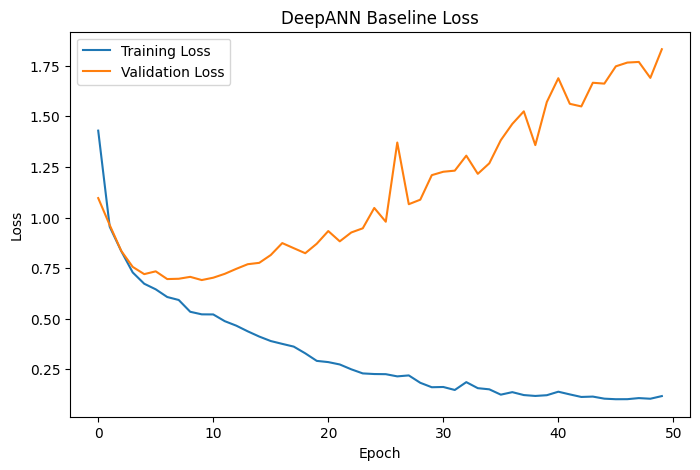

In [47]:
# ==============================================================
# BASELINE TRAINING CURVES
# ==============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    baseline_train_losses,
    label="Training Loss"
)

plt.plot(
    baseline_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DeepANN Baseline Loss")

plt.legend()
plt.show()

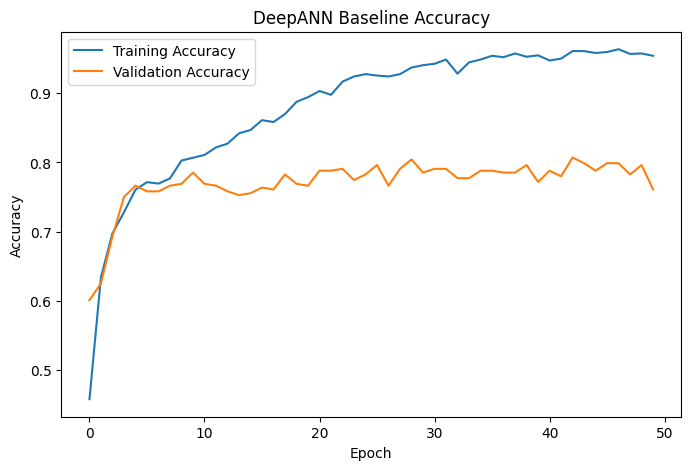

In [48]:
# ==============================================================
# BASELINE ACCURACY CURVE
# ==============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    baseline_train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    baseline_val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DeepANN Baseline Accuracy")

plt.legend()
plt.show()

In [49]:
# ==============================================================
# MODULE 2 — EXPERIMENT 1
# DEFAULT WEIGHT INITIALIZATION
# ==============================================================

def create_default_model():

    model = DeepSkinDiseaseANN(
        input_size=78,
        num_classes=6
    )

    return model


default_model = create_default_model()

default_criterion = nn.CrossEntropyLoss()

default_optimizer = optim.Adam(
    default_model.parameters(),
    lr=0.001
)

print("Default initialization experiment ready.")

Default initialization experiment ready.


In [50]:
# ==============================================================
# TRAIN DEFAULT INITIALIZATION MODEL
# ==============================================================

default_epochs = 50

default_train_losses = []
default_val_losses = []

default_train_accuracies = []
default_val_accuracies = []

best_default_val_loss = float("inf")

for epoch in range(default_epochs):

    # ----------------------------------------------------------
    # TRAINING
    # ----------------------------------------------------------

    default_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        default_optimizer.zero_grad()

        outputs = default_model(inputs)

        loss = default_criterion(outputs, labels)

        loss.backward()

        default_optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ----------------------------------------------------------
    # VALIDATION
    # ----------------------------------------------------------

    default_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = default_model(inputs)

            loss = default_criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    default_train_losses.append(train_loss)
    default_val_losses.append(val_loss)

    default_train_accuracies.append(train_accuracy)
    default_val_accuracies.append(val_accuracy)

    if val_loss < best_default_val_loss:

        best_default_val_loss = val_loss

        torch.save(
            default_model.state_dict(),
            "default_initialization_best.pth"
        )

    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1}/{default_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

print("\nDefault initialization training completed.")

Epoch [1/50] | Train Loss: 1.5189 | Train Acc: 0.5122 | Val Loss: 1.1536 | Val Acc: 0.6005
Epoch [5/50] | Train Loss: 0.6777 | Train Acc: 0.7476 | Val Loss: 0.7450 | Val Acc: 0.7473
Epoch [10/50] | Train Loss: 0.5663 | Train Acc: 0.8027 | Val Loss: 0.6850 | Val Acc: 0.7663
Epoch [15/50] | Train Loss: 0.4448 | Train Acc: 0.8395 | Val Loss: 0.7760 | Val Acc: 0.7853
Epoch [20/50] | Train Loss: 0.3400 | Train Acc: 0.8830 | Val Loss: 0.8835 | Val Acc: 0.7609
Epoch [25/50] | Train Loss: 0.2534 | Train Acc: 0.9068 | Val Loss: 0.9782 | Val Acc: 0.7826
Epoch [30/50] | Train Loss: 0.1946 | Train Acc: 0.9354 | Val Loss: 1.1245 | Val Acc: 0.7935
Epoch [35/50] | Train Loss: 0.1615 | Train Acc: 0.9476 | Val Loss: 1.2865 | Val Acc: 0.7989
Epoch [40/50] | Train Loss: 0.1312 | Train Acc: 0.9524 | Val Loss: 1.4543 | Val Acc: 0.8043
Epoch [45/50] | Train Loss: 0.1447 | Train Acc: 0.9497 | Val Loss: 1.5799 | Val Acc: 0.7989
Epoch [50/50] | Train Loss: 0.1136 | Train Acc: 0.9605 | Val Loss: 1.5830 | Val Ac

In [51]:
# ==============================================================
# EVALUATE DEFAULT INITIALIZATION
# ==============================================================

default_model.load_state_dict(
    torch.load("default_initialization_best.pth")
)

default_model.eval()

default_predictions = []
default_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = default_model(inputs)

        _, predicted = torch.max(outputs, 1)

        default_predictions.extend(
            predicted.numpy()
        )

        default_labels.extend(
            labels.numpy()
        )

default_accuracy = accuracy_score(
    default_labels,
    default_predictions
)

print("=" * 70)
print("DEFAULT INITIALIZATION RESULTS")
print("=" * 70)

print(
    f"\nTest Accuracy: "
    f"{default_accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        default_labels,
        default_predictions,
        target_names=label_encoder.classes_,
        digits=4
    )
)

DEFAULT INITIALIZATION RESULTS

Test Accuracy: 76.96%

Classification Report:
              precision    recall  f1-score   support

         ACK     0.8176    0.8288    0.8231       146
         BCC     0.7644    0.9408    0.8435       169
         MEL     0.6250    0.5000    0.5556        10
         NEV     0.7119    0.8571    0.7778        49
         SCC     0.0000    0.0000    0.0000        39
         SEK     0.7297    0.5745    0.6429        47

    accuracy                         0.7696       460
   macro avg     0.6081    0.6169    0.6071       460
weighted avg     0.7043    0.7696    0.7318       460



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
# ==============================================================
# STORE EXPERIMENT RESULT
# ==============================================================

module2_results = []

module2_results.append({
    "Experiment": "Default Initialization",
    "Optimizer": "Adam",
    "Learning Rate": 0.001,
    "Test Accuracy": default_accuracy
})

results_df = pd.DataFrame(module2_results)

display(results_df)

,Experiment,Optimizer,Learning Rate,Test Accuracy
0,Default Initialization,Adam,0.001,0.769565


In [53]:
# ==============================================================
# MODULE 2 — EXPERIMENT 2
# XAVIER / GLOROT INITIALIZATION
# ==============================================================

def xavier_initialize(model):

    for layer in model.modules():

        if isinstance(layer, nn.Linear):

            nn.init.xavier_uniform_(layer.weight)

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    return model


xavier_model = DeepSkinDiseaseANN(
    input_size=78,
    num_classes=6
)

xavier_model = xavier_initialize(
    xavier_model
)

xavier_criterion = nn.CrossEntropyLoss()

xavier_optimizer = optim.Adam(
    xavier_model.parameters(),
    lr=0.001
)

print("Xavier initialization applied successfully.")

Xavier initialization applied successfully.


In [54]:
# ==============================================================
# TRAIN XAVIER MODEL
# ==============================================================

xavier_epochs = 50

xavier_train_losses = []
xavier_val_losses = []

xavier_train_accuracies = []
xavier_val_accuracies = []

best_xavier_val_loss = float("inf")

for epoch in range(xavier_epochs):

    xavier_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        xavier_optimizer.zero_grad()

        outputs = xavier_model(inputs)

        loss = xavier_criterion(outputs, labels)

        loss.backward()

        xavier_optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    xavier_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = xavier_model(inputs)

            loss = xavier_criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    xavier_train_losses.append(train_loss)
    xavier_val_losses.append(val_loss)

    xavier_train_accuracies.append(train_accuracy)
    xavier_val_accuracies.append(val_accuracy)

    if val_loss < best_xavier_val_loss:

        best_xavier_val_loss = val_loss

        torch.save(
            xavier_model.state_dict(),
            "xavier_initialization_best.pth"
        )

    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1}/{xavier_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

print("\nXavier training completed.")

Epoch [1/50] | Train Loss: 1.4878 | Train Acc: 0.4190 | Val Loss: 1.2041 | Val Acc: 0.6359
Epoch [5/50] | Train Loss: 0.6129 | Train Acc: 0.7844 | Val Loss: 0.6961 | Val Acc: 0.7717
Epoch [10/50] | Train Loss: 0.4419 | Train Acc: 0.8408 | Val Loss: 0.6937 | Val Acc: 0.7690
Epoch [15/50] | Train Loss: 0.3297 | Train Acc: 0.8864 | Val Loss: 0.7487 | Val Acc: 0.7989
Epoch [20/50] | Train Loss: 0.2275 | Train Acc: 0.9231 | Val Loss: 0.8952 | Val Acc: 0.7908
Epoch [25/50] | Train Loss: 0.1738 | Train Acc: 0.9395 | Val Loss: 1.0674 | Val Acc: 0.8016
Epoch [30/50] | Train Loss: 0.1200 | Train Acc: 0.9551 | Val Loss: 1.3963 | Val Acc: 0.7935
Epoch [35/50] | Train Loss: 0.1381 | Train Acc: 0.9483 | Val Loss: 1.2940 | Val Acc: 0.7880
Epoch [40/50] | Train Loss: 0.1265 | Train Acc: 0.9517 | Val Loss: 1.6961 | Val Acc: 0.8071
Epoch [45/50] | Train Loss: 0.1075 | Train Acc: 0.9619 | Val Loss: 1.5955 | Val Acc: 0.7880
Epoch [50/50] | Train Loss: 0.1052 | Train Acc: 0.9619 | Val Loss: 1.7560 | Val Ac

In [55]:
# ==============================================================
# EVALUATE XAVIER MODEL
# ==============================================================

xavier_model.load_state_dict(
    torch.load("xavier_initialization_best.pth")
)

xavier_model.eval()

xavier_predictions = []
xavier_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = xavier_model(inputs)

        _, predicted = torch.max(outputs, 1)

        xavier_predictions.extend(
            predicted.numpy()
        )

        xavier_labels.extend(
            labels.numpy()
        )

xavier_accuracy = accuracy_score(
    xavier_labels,
    xavier_predictions
)

print("=" * 70)
print("XAVIER INITIALIZATION RESULTS")
print("=" * 70)

print(
    f"\nTest Accuracy: "
    f"{xavier_accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        xavier_labels,
        xavier_predictions,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

XAVIER INITIALIZATION RESULTS

Test Accuracy: 80.22%

Classification Report:
              precision    recall  f1-score   support

         ACK     0.8194    0.8699    0.8439       146
         BCC     0.8235    0.9112    0.8652       169
         MEL     0.7500    0.6000    0.6667        10
         NEV     0.7288    0.8776    0.7963        49
         SCC     0.6875    0.2821    0.4000        39
         SEK     0.8000    0.5957    0.6829        47

    accuracy                         0.8022       460
   macro avg     0.7682    0.6894    0.7092       460
weighted avg     0.7966    0.8022    0.7887       460



In [56]:
# ==============================================================
# MODULE 2 — EXPERIMENT 3
# HE / KAIMING INITIALIZATION
# ==============================================================

def he_initialize(model):

    for layer in model.modules():

        if isinstance(layer, nn.Linear):

            nn.init.kaiming_uniform_(
                layer.weight,
                nonlinearity="relu"
            )

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    return model


he_model = DeepSkinDiseaseANN(
    input_size=78,
    num_classes=6
)

he_model = he_initialize(
    he_model
)

he_criterion = nn.CrossEntropyLoss()

he_optimizer = optim.Adam(
    he_model.parameters(),
    lr=0.001
)

print("He/Kaiming initialization applied successfully.")

He/Kaiming initialization applied successfully.


In [57]:
# ==============================================================
# TRAIN HE / KAIMING MODEL
# ==============================================================

he_epochs = 50

he_train_losses = []
he_val_losses = []

he_train_accuracies = []
he_val_accuracies = []

best_he_val_loss = float("inf")

for epoch in range(he_epochs):

    # ----------------------------------------------------------
    # TRAINING
    # ----------------------------------------------------------

    he_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        he_optimizer.zero_grad()

        outputs = he_model(inputs)

        loss = he_criterion(outputs, labels)

        loss.backward()

        he_optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # ----------------------------------------------------------
    # VALIDATION
    # ----------------------------------------------------------

    he_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = he_model(inputs)

            loss = he_criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    he_train_losses.append(train_loss)
    he_val_losses.append(val_loss)

    he_train_accuracies.append(train_accuracy)
    he_val_accuracies.append(val_accuracy)

    # ----------------------------------------------------------
    # SAVE BEST MODEL
    # ----------------------------------------------------------

    if val_loss < best_he_val_loss:

        best_he_val_loss = val_loss

        torch.save(
            he_model.state_dict(),
            "he_initialization_best.pth"
        )

    # ----------------------------------------------------------
    # PROGRESS
    # ----------------------------------------------------------

    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch+1}/{he_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

print("\nHe/Kaiming training completed.")

Epoch [1/50] | Train Loss: 1.2482 | Train Acc: 0.5510 | Val Loss: 0.9288 | Val Acc: 0.6793
Epoch [5/50] | Train Loss: 0.6407 | Train Acc: 0.7680 | Val Loss: 0.7224 | Val Acc: 0.7527
Epoch [10/50] | Train Loss: 0.4917 | Train Acc: 0.8265 | Val Loss: 0.7046 | Val Acc: 0.7717
Epoch [15/50] | Train Loss: 0.3573 | Train Acc: 0.8714 | Val Loss: 0.7420 | Val Acc: 0.7908
Epoch [20/50] | Train Loss: 0.2524 | Train Acc: 0.9143 | Val Loss: 0.8146 | Val Acc: 0.7880
Epoch [25/50] | Train Loss: 0.1917 | Train Acc: 0.9340 | Val Loss: 1.0564 | Val Acc: 0.7826
Epoch [30/50] | Train Loss: 0.1664 | Train Acc: 0.9381 | Val Loss: 1.1100 | Val Acc: 0.7962
Epoch [35/50] | Train Loss: 0.1606 | Train Acc: 0.9401 | Val Loss: 1.2963 | Val Acc: 0.7989
Epoch [40/50] | Train Loss: 0.1305 | Train Acc: 0.9503 | Val Loss: 1.3933 | Val Acc: 0.7908
Epoch [45/50] | Train Loss: 0.1187 | Train Acc: 0.9565 | Val Loss: 1.4740 | Val Acc: 0.7962
Epoch [50/50] | Train Loss: 0.1166 | Train Acc: 0.9531 | Val Loss: 1.4987 | Val Ac

In [58]:
# ==============================================================
# EVALUATE HE / KAIMING MODEL
# ==============================================================

he_model.load_state_dict(
    torch.load("he_initialization_best.pth")
)

he_model.eval()

he_predictions = []
he_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = he_model(inputs)

        _, predicted = torch.max(outputs, 1)

        he_predictions.extend(
            predicted.numpy()
        )

        he_labels.extend(
            labels.numpy()
        )

he_accuracy = accuracy_score(
    he_labels,
    he_predictions
)

print("=" * 70)
print("HE / KAIMING INITIALIZATION RESULTS")
print("=" * 70)

print(
    f"\nTest Accuracy: "
    f"{he_accuracy * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        he_labels,
        he_predictions,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

HE / KAIMING INITIALIZATION RESULTS

Test Accuracy: 77.83%

Classification Report:
              precision    recall  f1-score   support

         ACK     0.8593    0.7945    0.8256       146
         BCC     0.8258    0.8698    0.8473       169
         MEL     0.6667    0.6000    0.6316        10
         NEV     0.7826    0.7347    0.7579        49
         SCC     0.4865    0.4615    0.4737        39
         SEK     0.6364    0.7447    0.6863        47

    accuracy                         0.7783       460
   macro avg     0.7095    0.7009    0.7037       460
weighted avg     0.7803    0.7783    0.7781       460



In [59]:
# ==============================================================
# UPDATE MODULE 2 RESULTS
# ==============================================================

module2_results.append({
    "Experiment": "Xavier / Glorot",
    "Optimizer": "Adam",
    "Learning Rate": 0.001,
    "Test Accuracy": xavier_accuracy
})

module2_results.append({
    "Experiment": "He / Kaiming",
    "Optimizer": "Adam",
    "Learning Rate": 0.001,
    "Test Accuracy": he_accuracy
})

results_df = pd.DataFrame(module2_results)

display(results_df)

,Experiment,Optimizer,Learning Rate,Test Accuracy
0,Default Initialization,Adam,0.001,0.769565
1,Xavier / Glorot,Adam,0.001,0.802174
2,He / Kaiming,Adam,0.001,0.778261


In [60]:
# ==============================================================
# MODULE 2 — LEARNING RATE EXPERIMENT
# ==============================================================

def train_xavier_lr(learning_rate, epochs=50):

    # Create fresh model
    model = DeepSkinDiseaseANN(
        input_size=78,
        num_classes=6
    )

    # Apply Xavier initialization
    model = xavier_initialize(model)

    # Loss
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    best_val_loss = float("inf")
    best_model_path = f"xavier_lr_{learning_rate}.pth"

    for epoch in range(epochs):

        # ------------------------------------------------------
        # TRAIN
        # ------------------------------------------------------

        model.train()

        for inputs, labels in train_loader:

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

        # ------------------------------------------------------
        # VALIDATION
        # ------------------------------------------------------

        model.eval()

        val_loss_total = 0.0
        val_total = 0

        with torch.no_grad():

            for inputs, labels in val_loader:

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                val_loss_total += (
                    loss.item() * inputs.size(0)
                )

                val_total += inputs.size(0)

        val_loss = val_loss_total / val_total

        # Save best model
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                model.state_dict(),
                best_model_path
            )

    # ----------------------------------------------------------
    # LOAD BEST MODEL
    # ----------------------------------------------------------

    model.load_state_dict(
        torch.load(best_model_path)
    )

    model.eval()

    predictions = []
    actual = []

    with torch.no_grad():

        for inputs, labels in test_loader:

            outputs = model(inputs)

            _, predicted = torch.max(
                outputs,
                1
            )

            predictions.extend(
                predicted.numpy()
            )

            actual.extend(
                labels.numpy()
            )

    accuracy = accuracy_score(
        actual,
        predictions
    )

    report = classification_report(
        actual,
        predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    macro_f1 = report["macro avg"]["f1-score"]

    return accuracy, macro_f1

In [61]:
# ==============================================================
# TEST DIFFERENT LEARNING RATES
# ==============================================================

learning_rates = [
    0.0001,
    0.001,
    0.01
]

learning_rate_results = []

for lr in learning_rates:

    print("=" * 60)
    print("Testing learning rate:", lr)
    print("=" * 60)

    accuracy, macro_f1 = train_xavier_lr(
        learning_rate=lr,
        epochs=50
    )

    learning_rate_results.append({
        "Learning Rate": lr,
        "Test Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"Accuracy: {accuracy * 100:.2f}%"
    )

    print(
        f"Macro F1: {macro_f1:.4f}"
    )

Testing learning rate: 0.0001
Accuracy: 78.91%
Macro F1: 0.7066
Testing learning rate: 0.001
Accuracy: 79.78%
Macro F1: 0.7021
Testing learning rate: 0.01
Accuracy: 75.22%
Macro F1: 0.5401


In [62]:
# ==============================================================
# LEARNING RATE RESULTS
# ==============================================================

learning_rate_df = pd.DataFrame(
    learning_rate_results
)

display(
    learning_rate_df.sort_values(
        by="Test Accuracy",
        ascending=False
    )
)

,Learning Rate,Test Accuracy,Macro F1
1,0.0010,0.797826,0.702083
0,0.0001,0.789130,0.706592
2,0.0100,0.752174,0.540106


In [63]:
# ==============================================================
# MODULE 2 — OPTIMIZER COMPARISON
# ==============================================================

def train_optimizer(optimizer_name, learning_rate=0.001, epochs=50):

    # Fresh model
    model = DeepSkinDiseaseANN(
        input_size=78,
        num_classes=6
    )

    # Xavier initialization
    model = xavier_initialize(model)

    # Loss
    criterion = nn.CrossEntropyLoss()

    # ----------------------------------------------------------
    # SELECT OPTIMIZER
    # ----------------------------------------------------------

    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "SGD":

        optimizer = optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "RMSprop":

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    else:

        raise ValueError(
            "Unknown optimizer"
        )

    best_val_loss = float("inf")

    model_path = (
        f"optimizer_{optimizer_name}.pth"
    )

    # ----------------------------------------------------------
    # TRAINING
    # ----------------------------------------------------------

    for epoch in range(epochs):

        model.train()

        for inputs, labels in train_loader:

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

        # ------------------------------------------------------
        # VALIDATION
        # ------------------------------------------------------

        model.eval()

        val_loss_total = 0.0
        val_total = 0

        with torch.no_grad():

            for inputs, labels in val_loader:

                outputs = model(inputs)

                loss = criterion(
                    outputs,
                    labels
                )

                val_loss_total += (
                    loss.item() * inputs.size(0)
                )

                val_total += inputs.size(0)

        val_loss = (
            val_loss_total / val_total
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                model.state_dict(),
                model_path
            )

    # ----------------------------------------------------------
    # TEST
    # ----------------------------------------------------------

    model.load_state_dict(
        torch.load(model_path)
    )

    model.eval()

    predictions = []
    actual = []

    with torch.no_grad():

        for inputs, labels in test_loader:

            outputs = model(inputs)

            _, predicted = torch.max(
                outputs,
                1
            )

            predictions.extend(
                predicted.numpy()
            )

            actual.extend(
                labels.numpy()
            )

    accuracy = accuracy_score(
        actual,
        predictions
    )

    report = classification_report(
        actual,
        predictions,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    macro_f1 = report[
        "macro avg"
    ]["f1-score"]

    return accuracy, macro_f1

In [64]:
# ==============================================================
# TEST DIFFERENT OPTIMIZERS
# ==============================================================

optimizers_to_test = [
    "Adam",
    "SGD",
    "RMSprop"
]

optimizer_results = []

for optimizer_name in optimizers_to_test:

    print("=" * 60)
    print(
        "Testing optimizer:",
        optimizer_name
    )
    print("=" * 60)

    accuracy, macro_f1 = train_optimizer(
        optimizer_name=optimizer_name,
        learning_rate=0.001,
        epochs=50
    )

    optimizer_results.append({
        "Optimizer": optimizer_name,
        "Learning Rate": 0.001,
        "Test Accuracy": accuracy,
        "Macro F1": macro_f1
    })

    print(
        f"Accuracy: {accuracy * 100:.2f}%"
    )

    print(
        f"Macro F1: {macro_f1:.4f}"
    )

Testing optimizer: Adam
Accuracy: 78.26%
Macro F1: 0.7087
Testing optimizer: SGD
Accuracy: 75.65%
Macro F1: 0.5174
Testing optimizer: RMSprop
Accuracy: 77.83%
Macro F1: 0.6817


In [65]:
# ==============================================================
# OPTIMIZER COMPARISON RESULTS
# ==============================================================

optimizer_df = pd.DataFrame(
    optimizer_results
)

display(
    optimizer_df.sort_values(
        by="Test Accuracy",
        ascending=False
    )
)

,Optimizer,Learning Rate,Test Accuracy,Macro F1
0,Adam,0.001,0.782609,0.708744
2,RMSprop,0.001,0.778261,0.681685
1,SGD,0.001,0.756522,0.517422


In [66]:
# ==============================================================
# MODULE 2 — FINAL OPTIMIZED DEEPANN
# ==============================================================
# Winning configuration:
# Xavier / Glorot initialization
# Adam optimizer
# Learning rate = 0.001
# ==============================================================

FINAL_INPUT_SIZE = 78
FINAL_NUM_CLASSES = 6

# Create fresh DeepANN
final_model = DeepSkinDiseaseANN(
    input_size=FINAL_INPUT_SIZE,
    num_classes=FINAL_NUM_CLASSES
)

# Apply Xavier initialization
final_model = xavier_initialize(final_model)

# Loss function
final_criterion = nn.CrossEntropyLoss()

# Adam optimizer
final_optimizer = optim.Adam(
    final_model.parameters(),
    lr=0.001
)

print("Final optimized DeepANN created.")
print("Initialization: Xavier / Glorot")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Input features:", FINAL_INPUT_SIZE)
print("Number of classes:", FINAL_NUM_CLASSES)

Final optimized DeepANN created.
Initialization: Xavier / Glorot
Optimizer: Adam
Learning rate: 0.001
Input features: 78
Number of classes: 6


In [67]:
# ==============================================================
# TRAIN FINAL OPTIMIZED DEEPANN
# ==============================================================

final_epochs = 50

final_train_losses = []
final_val_losses = []

final_train_accuracies = []
final_val_accuracies = []

best_final_val_loss = float("inf")
best_final_epoch = 0

for epoch in range(final_epochs):

    # ==========================================================
    # TRAINING
    # ==========================================================

    final_model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:

        final_optimizer.zero_grad()

        outputs = final_model(inputs)

        loss = final_criterion(
            outputs,
            labels
        )

        loss.backward()

        final_optimizer.step()

        running_train_loss += (
            loss.item() * inputs.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss / train_total
    )

    train_accuracy = (
        train_correct / train_total
    )

    final_train_losses.append(
        train_loss
    )

    final_train_accuracies.append(
        train_accuracy
    )

    # ==========================================================
    # VALIDATION
    # ==========================================================

    final_model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = final_model(inputs)

            loss = final_criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * inputs.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss / val_total
    )

    val_accuracy = (
        val_correct / val_total
    )

    final_val_losses.append(
        val_loss
    )

    final_val_accuracies.append(
        val_accuracy
    )

    # ==========================================================
    # SAVE BEST MODEL
    # ==========================================================

    if val_loss < best_final_val_loss:

        best_final_val_loss = val_loss

        best_final_epoch = epoch + 1

        torch.save(
            final_model.state_dict(),
            "DermaVision_Module2_Final_DeepANN.pth"
        )

    # ==========================================================
    # PRINT PROGRESS
    # ==========================================================

    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch + 1}/{final_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

print("\nFinal optimized model training completed.")

print(
    "Best epoch:",
    best_final_epoch
)

print(
    "Best validation loss:",
    round(best_final_val_loss, 4)
)

print(
    "\nModel saved as:"
)

print(
    "DermaVision_Module2_Final_DeepANN.pth"
)

Epoch [1/50] | Train Loss: 1.2849 | Train Acc: 0.5544 | Val Loss: 0.9156 | Val Acc: 0.7011
Epoch [5/50] | Train Loss: 0.6203 | Train Acc: 0.7619 | Val Loss: 0.7017 | Val Acc: 0.7554
Epoch [10/50] | Train Loss: 0.4433 | Train Acc: 0.8435 | Val Loss: 0.7228 | Val Acc: 0.7880
Epoch [15/50] | Train Loss: 0.3178 | Train Acc: 0.8939 | Val Loss: 0.7723 | Val Acc: 0.7908
Epoch [20/50] | Train Loss: 0.2200 | Train Acc: 0.9231 | Val Loss: 0.9273 | Val Acc: 0.7826
Epoch [25/50] | Train Loss: 0.1608 | Train Acc: 0.9415 | Val Loss: 1.2231 | Val Acc: 0.7826
Epoch [30/50] | Train Loss: 0.1272 | Train Acc: 0.9524 | Val Loss: 1.2641 | Val Acc: 0.7935
Epoch [35/50] | Train Loss: 0.1101 | Train Acc: 0.9565 | Val Loss: 1.4578 | Val Acc: 0.7799
Epoch [40/50] | Train Loss: 0.1374 | Train Acc: 0.9463 | Val Loss: 1.5660 | Val Acc: 0.7745
Epoch [45/50] | Train Loss: 0.1060 | Train Acc: 0.9585 | Val Loss: 1.7623 | Val Acc: 0.7772
Epoch [50/50] | Train Loss: 0.1188 | Train Acc: 0.9558 | Val Loss: 1.6589 | Val Ac

In [68]:
# ==============================================================
# LOAD BEST FINAL MODEL
# ==============================================================

final_model.load_state_dict(
    torch.load(
        "DermaVision_Module2_Final_DeepANN.pth",
        map_location=torch.device("cpu")
    )
)

final_model.eval()

print("Best final Module 2 model loaded successfully.")

Best final Module 2 model loaded successfully.


In [69]:
# ==============================================================
# FINAL MODULE 2 TEST EVALUATION
# ==============================================================

final_predictions = []
final_actual = []

final_test_loss = 0.0
final_test_total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = final_model(inputs)

        loss = final_criterion(
            outputs,
            labels
        )

        final_test_loss += (
            loss.item() * inputs.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        final_predictions.extend(
            predicted.numpy()
        )

        final_actual.extend(
            labels.numpy()
        )

        final_test_total += labels.size(0)

# Average test loss
final_test_loss = (
    final_test_loss / final_test_total
)

# Accuracy
final_test_accuracy = accuracy_score(
    final_actual,
    final_predictions
)

# Classification report
final_report = classification_report(
    final_actual,
    final_predictions,
    target_names=label_encoder.classes_,
    digits=4,
    zero_division=0
)

print("=" * 70)
print("FINAL MODULE 2 — OPTIMIZED DEEPANN")
print("=" * 70)

print(
    f"\nTest Loss: {final_test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{final_test_accuracy * 100:.2f}%"
)

print("\nClassification Report:")
print(final_report)

FINAL MODULE 2 — OPTIMIZED DEEPANN

Test Loss: 0.6147
Test Accuracy: 78.26%

Classification Report:
              precision    recall  f1-score   support

         ACK     0.8013    0.8562    0.8278       146
         BCC     0.7839    0.9231    0.8478       169
         MEL     1.0000    0.4000    0.5714        10
         NEV     0.7368    0.8571    0.7925        49
         SCC     0.6364    0.1795    0.2800        39
         SEK     0.7879    0.5532    0.6500        47

    accuracy                         0.7826       460
   macro avg     0.7910    0.6282    0.6616       460
weighted avg     0.7770    0.7826    0.7612       460



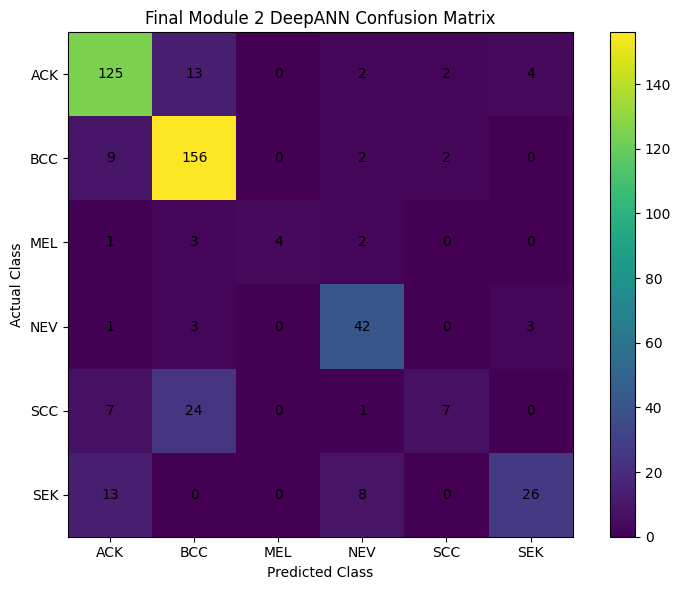

In [70]:
# ==============================================================
# FINAL CONFUSION MATRIX
# ==============================================================

cm = confusion_matrix(
    final_actual,
    final_predictions
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title(
    "Final Module 2 DeepANN Confusion Matrix"
)

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(len(cm)):

    for j in range(len(cm)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

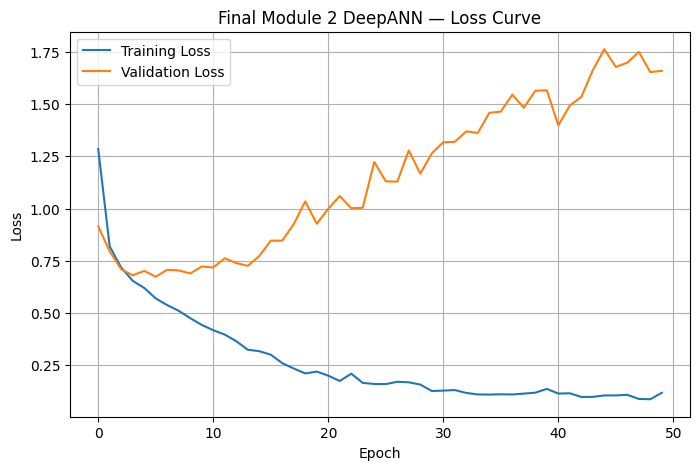

In [71]:
# ==============================================================
# LOSS CURVES
# ==============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_train_losses,
    label="Training Loss"
)

plt.plot(
    final_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Final Module 2 DeepANN — Loss Curve"
)

plt.legend()

plt.grid(True)

plt.show()

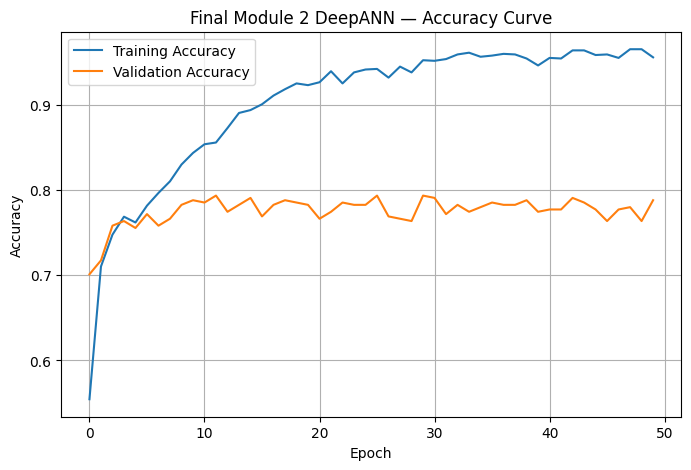

In [72]:
# ==============================================================
# ACCURACY CURVES
# ==============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    final_val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Final Module 2 DeepANN — Accuracy Curve"
)

plt.legend()

plt.grid(True)

plt.show()

In [73]:
# ==============================================================
# MODULE 2 — FINAL EXPERIMENT COMPARISON
# ==============================================================

comparison_data = [

    {
        "Experiment": "Module 1 DeepANN Baseline",
        "Initialization": "Default",
        "Optimizer": "Adam",
        "Learning Rate": 0.001,
        "Test Accuracy": 0.7696,
        "Macro F1": 0.5873
    },

    {
        "Experiment": "Default Initialization",
        "Initialization": "Default",
        "Optimizer": "Adam",
        "Learning Rate": 0.001,
        "Test Accuracy": 0.7696,
        "Macro F1": 0.6071
    },

    {
        "Experiment": "Xavier / Glorot",
        "Initialization": "Xavier",
        "Optimizer": "Adam",
        "Learning Rate": 0.001,
        "Test Accuracy": 0.8022,
        "Macro F1": 0.7092
    },

    {
        "Experiment": "He / Kaiming",
        "Initialization": "He",
        "Optimizer": "Adam",
        "Learning Rate": 0.001,
        "Test Accuracy": 0.7783,
        "Macro F1": 0.7037
    },

    {
        "Experiment": "Xavier + LR 0.0001",
        "Initialization": "Xavier",
        "Optimizer": "Adam",
        "Learning Rate": 0.0001,
        "Test Accuracy": 0.7891,
        "Macro F1": 0.7066
    },

    {
        "Experiment": "Xavier + LR 0.001",
        "Initialization": "Xavier",
        "Optimizer": "Adam",
        "Learning Rate": 0.001,
        "Test Accuracy": 0.7978,
        "Macro F1": 0.7021
    },

    {
        "Experiment": "Xavier + LR 0.01",
        "Initialization": "Xavier",
        "Optimizer": "Adam",
        "Learning Rate": 0.01,
        "Test Accuracy": 0.7522,
        "Macro F1": 0.5401
    },

    {
        "Experiment": "Xavier + RMSprop",
        "Initialization": "Xavier",
        "Optimizer": "RMSprop",
        "Learning Rate": 0.001,
        "Test Accuracy": 0.7783,
        "Macro F1": 0.6817
    },

    {
        "Experiment": "Xavier + SGD",
        "Initialization": "Xavier",
        "Optimizer": "SGD",
        "Learning Rate": 0.001,
        "Test Accuracy": 0.7565,
        "Macro F1": 0.5174
    }
]

comparison_df = pd.DataFrame(
    comparison_data
)

comparison_df = comparison_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

display(comparison_df)

,Experiment,Initialization,Optimizer,Learning Rate,Test Accuracy,Macro F1
2,Xavier / Glorot,Xavier,Adam,0.0010,0.8022,0.7092
5,Xavier + LR 0.001,Xavier,Adam,0.0010,0.7978,0.7021
4,Xavier + LR 0.0001,Xavier,Adam,0.0001,0.7891,0.7066
7,Xavier + RMSprop,Xavier,RMSprop,0.0010,0.7783,0.6817
3,He / Kaiming,He,Adam,0.0010,0.7783,0.7037
0,Module 1 DeepANN Baseline,Default,Adam,0.0010,0.7696,0.5873
1,Default Initialization,Default,Adam,0.0010,0.7696,0.6071
8,Xavier + SGD,Xavier,SGD,0.0010,0.7565,0.5174
6,Xavier + LR 0.01,Xavier,Adam,0.0100,0.7522,0.5401


In [74]:
# ==============================================================
# SAVE MODULE 2 RESULTS
# ==============================================================

comparison_df.to_csv(
    "DermaVision_Module2_Experiment_Results.csv",
    index=False
)

print(
    "Module 2 experiment results saved successfully."
)

Module 2 experiment results saved successfully.


In [75]:
# ==============================================================
# MODULE 2 — OUTPUT FOLDER
# ==============================================================

import os

OUTPUT_DIR = "/content/drive/MyDrive/dermavision_ai"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder:")
print(OUTPUT_DIR)

Output folder:
/content/drive/MyDrive/dermavision_ai


In [76]:
torch.save(
    final_model.state_dict(),
    os.path.join(
        OUTPUT_DIR,
        "DermaVision_Module2_Final_DeepANN.pth"
    )
)

In [77]:
# ==============================================================
# LOAD BEST FINAL MODEL
# ==============================================================

final_model.load_state_dict(
    torch.load(
        os.path.join(
            OUTPUT_DIR,
            "DermaVision_Module2_Final_DeepANN.pth"
        ),
        map_location=torch.device("cpu")
    )
)

final_model.eval()

print("Best final Module 2 model loaded successfully.")

Best final Module 2 model loaded successfully.


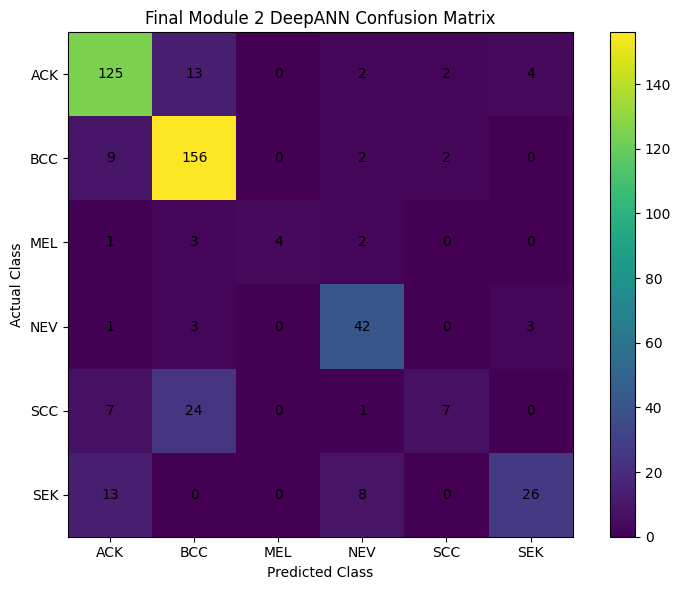

Saved:
/content/drive/MyDrive/dermavision_ai/Module2_Final_Confusion_Matrix.png


In [78]:
# ==============================================================
# FINAL CONFUSION MATRIX
# ==============================================================

cm = confusion_matrix(
    final_actual,
    final_predictions
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title(
    "Final Module 2 DeepANN Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

# SAVE GRAPH
confusion_matrix_path = os.path.join(
    OUTPUT_DIR,
    "Module2_Final_Confusion_Matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(confusion_matrix_path)

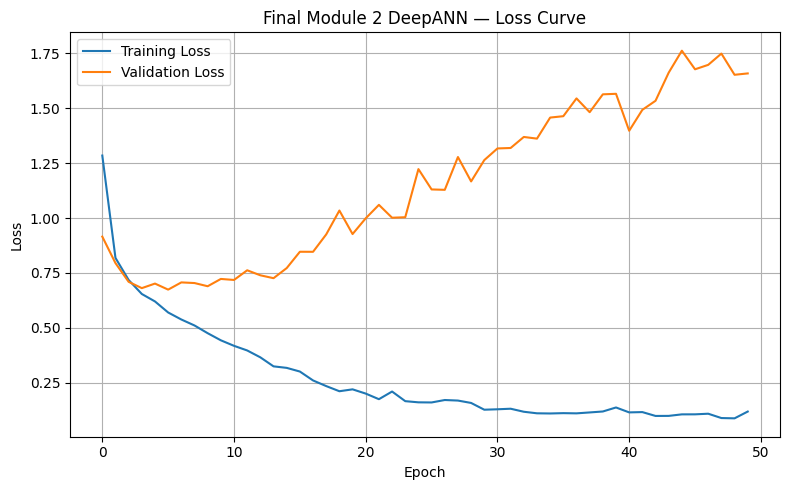

Saved:
/content/drive/MyDrive/dermavision_ai/Module2_Final_Loss_Curve.png


In [79]:
# ==============================================================
# LOSS CURVES
# ==============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_train_losses,
    label="Training Loss"
)

plt.plot(
    final_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Final Module 2 DeepANN — Loss Curve"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

# SAVE GRAPH
loss_graph_path = os.path.join(
    OUTPUT_DIR,
    "Module2_Final_Loss_Curve.png"
)

plt.savefig(
    loss_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(loss_graph_path)

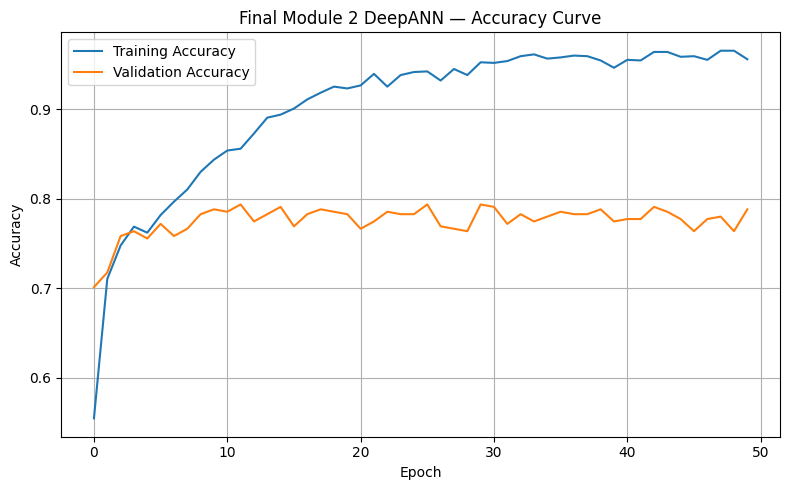

Saved:
/content/drive/MyDrive/dermavision_ai/Module2_Final_Accuracy_Curve.png


In [80]:
# ==============================================================
# ACCURACY CURVES
# ==============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    final_train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    final_val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Final Module 2 DeepANN — Accuracy Curve"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

# SAVE GRAPH
accuracy_graph_path = os.path.join(
    OUTPUT_DIR,
    "Module2_Final_Accuracy_Curve.png"
)

plt.savefig(
    accuracy_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(accuracy_graph_path)

In [81]:
# ==============================================================
# SAVE MODULE 2 RESULTS
# ==============================================================

results_path = os.path.join(
    OUTPUT_DIR,
    "DermaVision_Module2_Experiment_Results.csv"
)

comparison_df.to_csv(
    results_path,
    index=False
)

print("Module 2 experiment results saved successfully.")
print(results_path)

Module 2 experiment results saved successfully.
/content/drive/MyDrive/dermavision_ai/DermaVision_Module2_Experiment_Results.csv


In [82]:
# ==============================================================
# SAVE FINAL CLASSIFICATION REPORT
# ==============================================================

report_path = os.path.join(
    OUTPUT_DIR,
    "Module2_Final_Classification_Report.txt"
)

with open(report_path, "w") as f:

    f.write(
        "DERMAVISION AI — MODULE 2\n"
    )

    f.write(
        "FINAL OPTIMIZED DEEPANN\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        "Initialization: Xavier / Glorot\n"
    )

    f.write(
        "Optimizer: Adam\n"
    )

    f.write(
        "Learning Rate: 0.001\n\n"
    )

    f.write(
        f"Test Loss: {final_test_loss:.4f}\n"
    )

    f.write(
        f"Test Accuracy: "
        f"{final_test_accuracy * 100:.2f}%\n\n"
    )

    f.write(
        "Classification Report:\n"
    )

    f.write(
        final_report
    )

print("Classification report saved:")
print(report_path)

Classification report saved:
/content/drive/MyDrive/dermavision_ai/Module2_Final_Classification_Report.txt
